In [1]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit

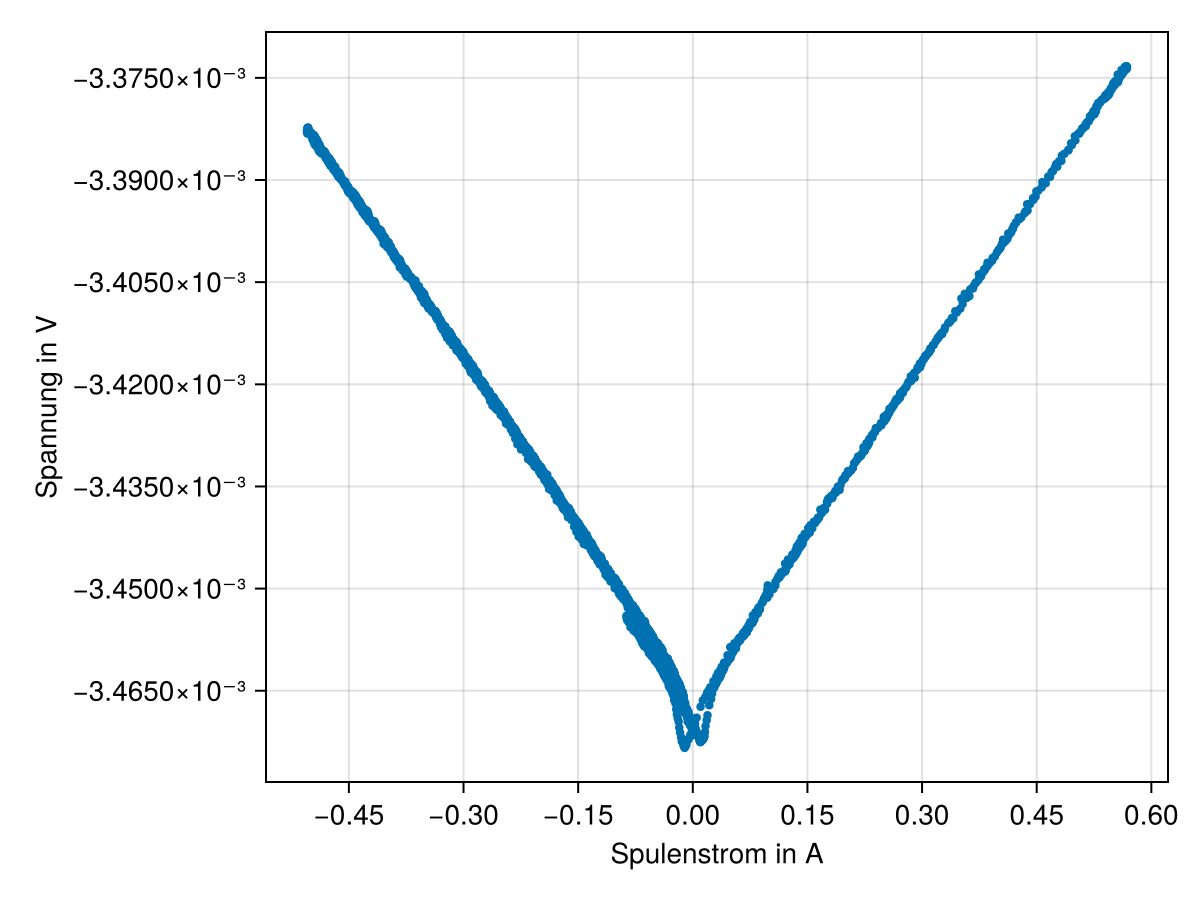

In [5]:
messung = readdlm("Hspule_strom_senkrecht", skipstart=2)

I = messung[:,1]
U = messung[:,2]

fig = Figure()
ax = Axis(fig[1,1], xlabel = "Spulenstrom in A", ylabel ="Spannung in V",
 xticks=LinearTicks(8), yticks=LinearTicks(8))

scatter!(ax, I, U, markersize=6)
fig


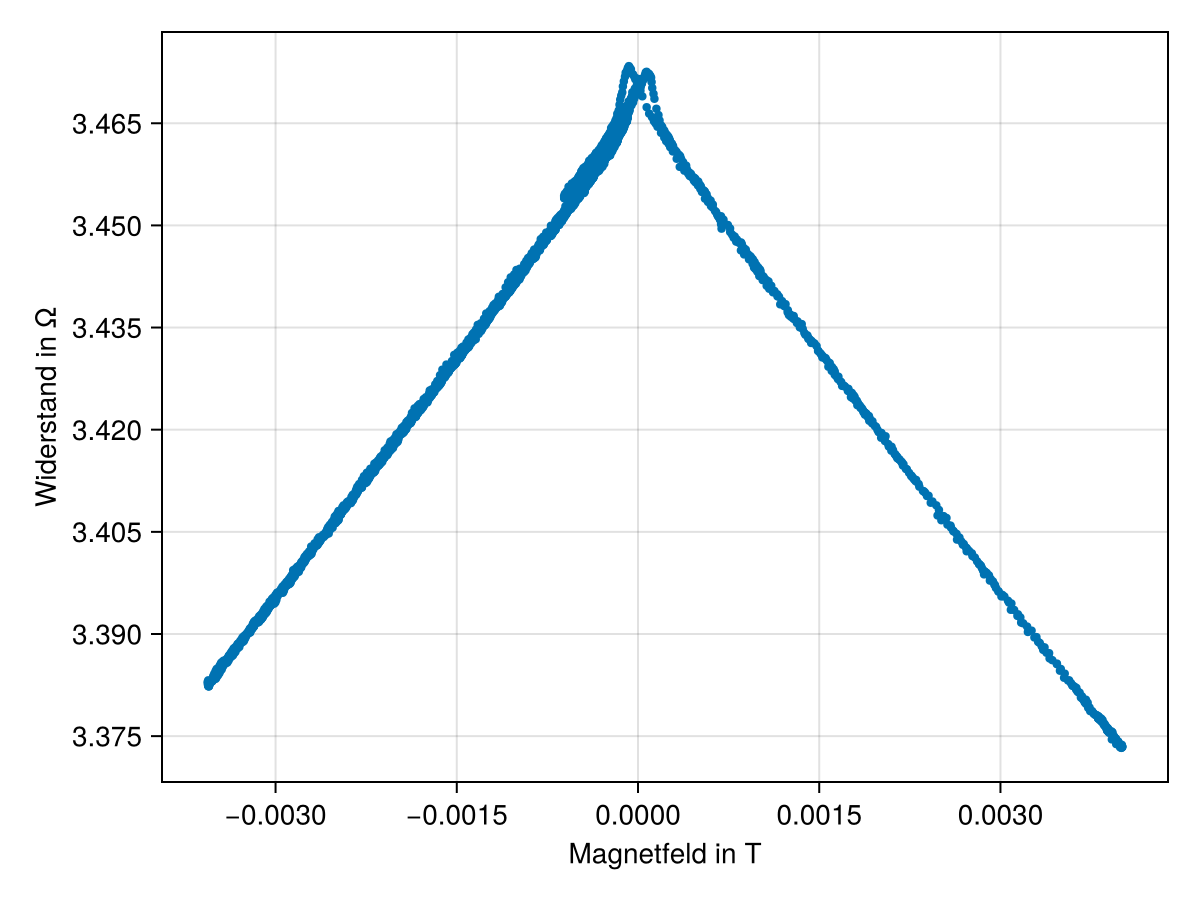

In [6]:
#Berechnen von R und B 

μ0 = 4π*1e-7
N =510 #Mittelwert der beiden N ergebnisse
r = 0.065 #cm to m 
c = (4/5)^(3/2)
I_probe = 1e-3 #in A 

B = I .* (c*μ0*N/r)
R = abs.(U ./ I_probe) 

#Seh hohen einzelwert wegnehm
maskR =  (R .> -800) .&  (R .< 4000)
B_r = B[maskR]
R_r = R[maskR]

fig3 = Figure()
ax = Axis(fig3[1,1], xlabel = "Magnetfeld in T", ylabel ="Widerstand in Ω",
 xticks=LinearTicks(8), yticks=LinearTicks(10))

scatter!(ax, B, R, markersize=6)
fig3

In [7]:
#Bestimmung des GMR-Effekts in Prozent

R_max = maximum(R)
R_min = minimum(R)

GMR = (R_max - R_min)/R_min * 100

println("R_max= $(round(R_max, digits=3)) Ω")
println("R_min=$(round(R_min,digits=3)) Ω")
println("GMR = $(round(GMR, digits=1)) %")

R_max= 3.473 Ω
R_min=3.373 Ω
GMR = 3.0 %


In [8]:
save("Spannung_Strom_senkrecht.pdf",fig)
save("R_vs_B_senkrecht.pdf",fig3)

CairoMakie.Screen{PDF}
